# Matching pipeline

The comparison method is used in statistical analysis to eliminate distortions caused by differences in the basic characteristics of the studied groups. Simply put, matching helps to make sure that the results of the experiment are really caused by the studied effect, and not by external factors.

Matching is most often performed in cases where the use of a standard AB test is impossible.

In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hypex import Matching
from hypex.dataset import (
    Dataset,
    FeatureRole,
    GroupingRole,
    InfoRole,
    TargetRole,
    TreatmentRole,
)
from hypex.utils import create_test_data

/Users/danilsamsutdinov/HypEx/.venv/lib/python3.11/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


# Create synthetic data

In [2]:
df = create_test_data().bfill()
df["post_spends"] = df["pre_spends"] + np.random.rand(len(df))
df[["signup_month", "treat"]] = df[["signup_month", "treat"]].astype(int)
df

,user_id,signup_month,treat,pre_spends,post_spends,age,gender,industry
0,0.0,0,0,497.0,497.650649,45.0,F,Finance
1,1.0,0,0,498.5,499.175571,41.0,F,Logistics
2,2.0,11,1,487.5,488.176944,59.0,F,E-commerce
3,3.0,0,0,486.5,486.887177,22.0,F,Finance
4,4.0,0,0,471.0,471.595623,42.0,F,Finance
...,...,...,...,...,...,...,...,...
9995,9995.0,9,1,497.5,498.484476,55.0,F,Finance
9996,9996.0,8,1,465.0,465.369731,34.0,M,Finance
9997,9997.0,10,1,459.5,460.438997,46.0,F,Logistics
9998,9998.0,1,1,532.0,532.160719,36.0,M,E-commerce


Basic statistics for numerical features:


,user_id,signup_month,treat,pre_spends,post_spends,age
count,10000.0,10000.00,10000.0,10000.00,10000.00,10000.00
mean,4999.6,3.01,0.5,487.28,487.79,43.43
std,2886.9,3.73,0.5,18.83,18.83,14.88
min,0.0,0.00,0.0,429.00,429.94,18.00
25%,2500.5,0.00,0.0,475.00,475.54,30.00
50%,5000.0,1.00,1.0,485.50,486.26,43.00
75%,7499.5,6.00,1.0,497.50,498.04,56.00
max,9999.0,11.00,1.0,576.00,577.00,69.00


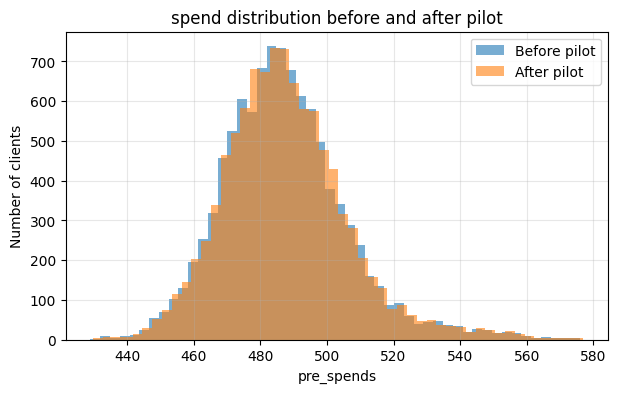

In [3]:
def describe_basic_info(df: pd.DataFrame):
    print("Basic statistics for numerical features:")
    display(df.describe().round(2))

def describe_cltv_effect(df: pd.DataFrame, group_col="treat"):
    result = (
        df.groupby(group_col)[["pre_spends", "post_spends"]]
        .mean()
        .rename(columns={"pre_spends": "mean_pre_spends", "post_spends": "mean_post_spends"})
    )
    result["delta_spend"] = result["post_spends"] - result["pre_spends"]
    print("Average spend before and after pilot:")
    print(result.round(2))
    result.plot(
        kind="bar",
        figsize=(6, 4),
        title="Average spend before and after pilot by groups",
        rot=0
    )
    plt.ylabel("Average spend")
    plt.grid(alpha=0.3)
    plt.show()

    return result

def plot_cltv_distribution(df: pd.DataFrame):
    plt.figure(figsize=(7, 4))
    plt.hist(df["pre_spends"], bins=50, alpha=0.6, label="Before pilot")
    plt.hist(df["post_spends"], bins=50, alpha=0.6, label="After pilot")
    plt.title("spend distribution before and after pilot")
    plt.xlabel("pre_spends")
    plt.ylabel("Number of clients")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def full_dataset_report(df: pd.DataFrame):
    describe_basic_info(df)
    plot_cltv_distribution(df)

full_dataset_report(df)

# Define the Dataset

In [4]:
data = Dataset(
    roles={
        "user_id": InfoRole(int),
        "treat": TreatmentRole(int),
        "post_spends": TargetRole(float),
        "gender": FeatureRole(str),
        "pre_spends": FeatureRole(float),
        "industry": FeatureRole(str),
        "age": FeatureRole(int),
    },
    data=df,
    default_role=InfoRole(),
)
data

,user_id,signup_month,treat,pre_spends,post_spends,age,gender,industry
0,0,0,0,497.0,497.650649,45,F,Finance
1,1,0,0,498.5,499.175571,41,F,Logistics
2,2,11,1,487.5,488.176944,59,F,E-commerce
3,3,0,0,486.5,486.887177,22,F,Finance
4,4,0,0,471.0,471.595623,42,F,Finance
...,...,...,...,...,...,...,...,...
9995,9995,9,1,497.5,498.484476,55,F,Finance
9996,9996,8,1,465.0,465.369731,34,M,Finance
9997,9997,10,1,459.5,460.438997,46,F,Logistics
9998,9998,1,1,532.0,532.160719,36,M,E-commerce


In [5]:
data.roles

{'user_id': Info(<class 'int'>),
 'treat': Treatment(<class 'int'>),
 'post_spends': Target(<class 'float'>),
 'gender': Feature(data_type=<class 'str'>),
 'pre_spends': Feature(data_type=<class 'float'>),
 'industry': Feature(data_type=<class 'str'>),
 'age': Feature(data_type=<class 'int'>),
 'signup_month': Info(<class 'int'>)}

# Basic Matching without parameters

Main matching steps (in HypEx):

1. **Dummy Encoder**
   Converts categorical features to numerical format 

2. **Distance matrix calculation (usually Mahalanobis)**
   
3. **Finding nearest pairs (via FAISS)**
   
4. **Quality check of twin matching**

5. **Effect estimation (ATT, ATC, ATE)**

In [6]:
data = data.fillna(method="bfill")
test = Matching()
result = test.execute(data)

/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1230: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
/Users/danilsamsutdinov/HypEx/hypex/dataset/backends/pandas_backend.py:1230: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return int(self.data[group_cols].nunique())
2026-09-22 21:05:43 | ERROR    | hypex.experiment | ✗ Process failed: Chi2Test after 0.010s - ValueError: cannot reindex on an axis with duplicate labels
2026-09-22 21:05:43 | ERROR    | hypex.experiment | ✗ Process failed: OnRoleExperiment after 0.340s - ValueError: cannot reindex on an axis with duplicate labels


ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
result.resume

### ATT — Average Treatment effect on the Treated

$
ATT = E[Y(1) - Y(0) \mid T=1]
$
 - shows **how the treatment affected those who actually received it**.

### ATC — Average Treatment effect on the Controls 

$
ATC = E[Y(1) - Y(0) \mid T=0]
$
 - shows **what would have happened to the control group if they had received the treatment**.

### ATE — Average Treatment Effect

$
ATE = E[Y(1) - Y(0)]
$
- the overall average effect in the population — a combination of ATT and ATC, weighted by group sizes.

In [ ]:
result.indexes

In [ ]:
result.full_data

## Distances: `distance="mahalanobis"` or `"l2"`

### 🔸 Euclidean (L2)

This is the classic metric:
$ d(x_i, x_j) = \sqrt{\sum_k (x_{ik} - x_{jk})^2} $
Simply measures the "geometric" distance between points in feature space.

### 🔸 Mahalanobis distance

A more advanced metric:
$ d_M(x_i, x_j) = \sqrt{(x_i - x_j)^T \Sigma^{-1} (x_i - x_j)} $
where $\Sigma$ is the covariance matrix of features.
This metric accounts for the scale and correlation of features, making the comparison more accurate:

In [ ]:
test = Matching(distance='l2')
result = test.execute(data)

In [ ]:
result.resume

In [ ]:
test = Matching(distance='mahalanobis')
result = test.execute(data)

In [ ]:
result.resume

# `group_match`: matching by groups

The parameter `group_match=True` forces HypEx to aggregate observations into groups (by a specified identifier), and then search for pairs between groups rather than individual objects.
This reduces variability at the individual level and allows for effect estimation at more aggregated levels.

In [ ]:
data = Dataset(
    roles={
        "user_id": InfoRole(int),
        "treat": TreatmentRole(int),
        "post_spends": TargetRole(float),
        "gender": GroupingRole(str),
        "pre_spends": FeatureRole(float),
        "industry": FeatureRole(str),
        "age": FeatureRole(int),
    },
    data=df,
    default_role=InfoRole(),
)
data['gender'].unique()

We can change **metric** and do estimation again.

In [ ]:
test = Matching(group_match=True)
result = test.execute(data)

In [ ]:
result.resume

# `bias_estimation`: bias estimation and correction

When `bias_estimation=True`, HypEx:

1. **Estimates residual imbalance** across all features after matching (e.g., using standardized mean difference, t-tests, etc.);
2. **Corrects the final effect estimate** to reduce the impact of remaining bias.


In [ ]:
data = Dataset(
    roles={
        "user_id": InfoRole(int),
        "treat": TreatmentRole(int),
        "post_spends": TargetRole(float),
        "gender": FeatureRole(str),
        "pre_spends": FeatureRole(float),
        "industry": FeatureRole(str),
        "age": FeatureRole(int),
    },
    data=df,
    default_role=InfoRole(),
)

In [ ]:
test = Matching(bias_estimation=False)
result = test.execute(data)

In [ ]:
result.resume

# `quality_tests`: matching quality checks

Main tests:

* `'ks-test'` — Kolmogorov–Smirnov test for comparing distributions;
* `'t-test'` — test for equality of means;
* `'chi2-test'` — test for independence of categorical features;

These tests help understand whether balance was achieved and how reliable the result can be considered.

In [ ]:
test = Matching(quality_tests=['chi2-test', 'ks-test', 't-test'])
result = test.execute(data)

In [ ]:
result.resume

In [ ]:
result.quality_results

# `faiss_mode`: search acceleration

FAISS is a high-performance library for nearest neighbor search, developed by Meta AI.
HypEx uses it for finding pairs in large datasets.

Modes:

* `'base'` — exact but slow search;
* `'fast'` — approximate but fast (uses indexing);
* `'auto'` — HypEx automatically chooses the optimal option depending on data size.


In [ ]:
test = Matching(faiss_mode="base")
result = test.execute(data)
result.resume

Finally, we may search pairs in L2 distance. 

In [ ]:
test = Matching(faiss_mode="fast")
result = test.execute(data)
result.resume

# `n_neighbors`: number of neighbors

Determines how many control objects will be matched for each object from the treatment group.

* `n_neighbors=1` — classic **one-to-one matching**;
* `n_neighbors>1` — **one-to-many matching**, when one treated object corresponds to multiple control objects.


In [ ]:
test = Matching(n_neighbors=3)
result = test.execute(data)
result.resume

In [ ]:
result.indexes

In [ ]:
result.full_data

# `weights`: feature weights

Not all features may be equally important for matching pairs.
The `weights` parameter allows you to explicitly set priorities for features.


In [ ]:
test = Matching(weights={"gender": 0.2, "industry": 0.3, "age": 0.1, "signup_month": 0.1, "pre_spends": 0.3})
result = test.execute(data)
result.resume

# `encode_categories`: encoding categorical features

If `encode_categories=True` (default), HypEx automatically converts categorical features to numerical form (one-hot encoding).
If False — the library expects that the user has already encoded them.
This step is necessary so that all features can participate in distance calculations.


In [ ]:
test = Matching(encode_categories=False)
result = test.execute(data)
result.resume